# CROCUS Data Access

This notebook demonstrates how to access sensor data from the CROCUS 
(Community Research on Climate and Urban Science) network of Sage/Waggle 
nodes deployed across Chicago.

The best way to check current sensor availability and recent data is through 
the Sage portal:
  - All nodes: https://portal.sagecontinuum.org/nodes
  - NEIU node:  https://portal.sagecontinuum.org/nodes/W08D

Further documentation:
  - Sage Data Client: https://github.com/sagecontinuum/sage-data-client
  - CROCUS Instrument Cookbooks: https://crocus-urban.github.io/instrument-cookbooks/

## Why sage_utils?

The Sage Data Client returns data in long format — one row per measurement — 
with variable names, metadata, and fill values that require consistent handling. 
The functions in `sage_utils.py` handle this wrangling automatically, returning 
clean wide-format DataFrames with intuitive column names, missing values replaced 
with NaN, and data resampled to a consistent 5-minute resolution regardless of 
the underlying sampling rate.

This makes it straightforward to load any sensor type with a single function 
call and compare data across years and sites without worrying about format 
differences.

## Network Notes

- All CROCUS WXT and AQT nodes were offline approximately December 2025 – 
  March 2026 during a network-wide maintenance period.
- The 5-minute averaging plugin was deployed across all nodes when they came 
  back online in April 2026. Historical WXT data prior to this transition was 
  sampled at >1Hz; historical AQT data was at 1-minute intervals.
- All data returned by the query functions is resampled to 5-minute means for 
  consistency across years.

In [1]:
import datetime as dt
import ssl

import matplotlib.pyplot as plt
import pandas as pd
import sage_data_client 

import importlib
import sage_utils
importlib.reload(sage_utils)
from sage_utils import CROCUS_NODES, query_aqt, query_wxt, query_sapflow, query_mfr, last_n_hours 

ssl._create_default_https_context = ssl._create_unverified_context

## CROCUS Node Dictionary

The `CROCUS_NODES` dictionary in `sage_utils.py` maps site abbreviations to 
Sage/Waggle node IDs. All query functions accept these node IDs as the `vsn` 
argument. To see available nodes:

In [2]:
for name, vsn in CROCUS_NODES.items():
    print(f'{name}: {vsn}')

ATMOS: W0A4
BIG: W0A0
CCICS: W08B
CSU: W08E
HUM: W0A1
NEIU: W08D
NU: W099
SHEDD: W09E
UIC: W096


In [3]:
# Select the node to query throughout this notebook.
# Change the site name here to switch to a different CROCUS location.
VSN = CROCUS_NODES['NEIU']
SITE_NAME = {vsn: name for name, vsn in CROCUS_NODES.items()}
print(f"Querying: {SITE_NAME[VSN]}({VSN})")

Querying: NEIU(W08D)


## WXT

### Recent Data (Last N hours)

In [4]:
# To see documentation for any function, type the function name followed by ?
# e.g.:
query_wxt?

Signature: query_wxt(vsn, start, end=None, resample='5min')
Docstring:
Query WXT weather data from the Sage/Waggle API for a single node.
NB: Historical WXT data (pre-2025 approx.) was sampled at >1Hz,
resulting in ~1M rows per day. Current data is averaged to 5-minute
intervals server-side. The 5-minute resample in query_wxt() handles
both cases correctly.

Parameters
----------
vsn : str
    Node ID, e.g. 'W08D'
start : str
    Start datetime, absolute e.g. '2023-06-01' or relative e.g. '-1h'
end : str, optional
    End datetime. If omitted, defaults to now.
resample : str, optional
    Pandas offset string for output resolution, e.g. '1min', '5min', '1h'.
    Default is RESAMPLE_INTERVAL. Should be >= native data resolution.    

Returns
-------
 pd.DataFrame resampled to `resample` interval with UTC DatetimeIndex
 and columns:
    humidity, pressure, temp, rain, wind_dir, wind_speed, vsn, sensor
File:      ~/py/crocus/sage_utils.py
Type:      function

In [5]:
start, end = last_n_hours(1)  # return(N) a (start,end) tuple for last N hours
wxt_last_hour = query_wxt(VSN,start,end)       
wxt_last_hour.head()

,humidity,pressure,temp,rain,wind_dir,wind_speed,vsn,sensor
timestamp,,,,,,,,
2026-05-23 17:25:00+00:00,73.707,992.820,16.813,19.02,77.544,2.033,W08D,vaisala-wxt536
2026-05-23 17:30:00+00:00,74.063,992.821,16.642,19.02,90.670,1.738,W08D,vaisala-wxt536
2026-05-23 17:35:00+00:00,75.042,992.785,16.469,19.02,55.842,1.889,W08D,vaisala-wxt536
2026-05-23 17:40:00+00:00,75.310,992.721,16.546,19.02,39.564,2.007,W08D,vaisala-wxt536
2026-05-23 17:45:00+00:00,74.584,992.720,16.756,19.02,75.338,1.738,W08D,vaisala-wxt536


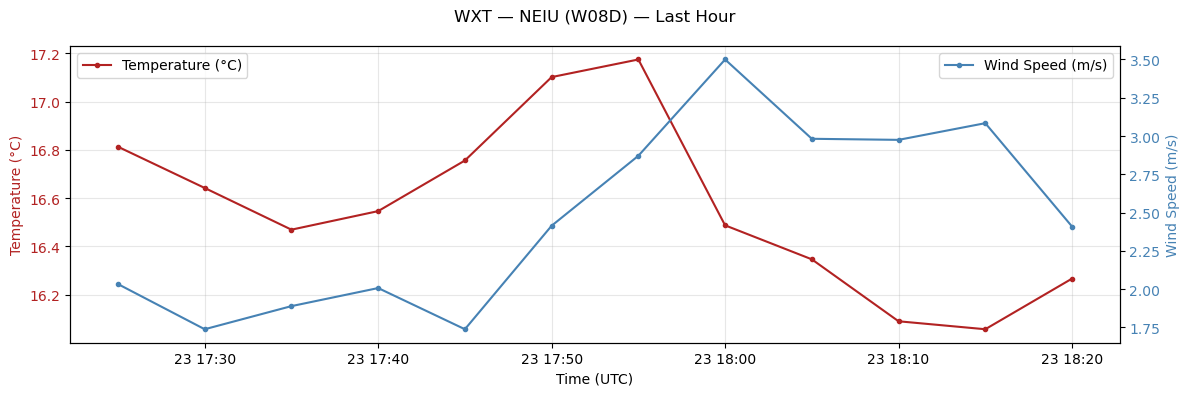

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 4))


ax1.plot(wxt_last_hour.index, wxt_last_hour['temp'],
         marker='o', markersize=3, color='firebrick',
         label='Temperature (°C)')
ax1.set_ylabel('Temperature (°C)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')
ax1.set_xlabel('Time (UTC)')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(wxt_last_hour.index, wxt_last_hour['wind_speed'],
         marker='o', markersize=3, color='steelblue', 
         label='Wind Speed (m/s)')
ax2.set_ylabel('Wind Speed (m/s)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
fig.suptitle(f'WXT — {SITE_NAME[VSN]} ({VSN}) — Last Hour', fontsize=12)
fig.tight_layout()
plt.show()

## AQT

Several nodes have PM sensors which stopped functioning. That is reflected in the plots below.

In [7]:
start, end = last_n_hours(1)
aqt_last_hour = query_aqt(VSN,start,end)       
aqt_last_hour.head()

,humidity,pressure,temp,co,no,no2,o3,pm1,pm10,pm25,vsn,sensor
timestamp,,,,,,,,,,,,
2026-05-23 17:25:00+00:00,67.3,942.8,18.2,0.074,0.0,0.018,0.010,0.0,0.0,0.0,W08D,vaisala-aqt530
2026-05-23 17:30:00+00:00,68.9,942.4,17.8,0.049,0.0,0.017,0.010,0.0,0.0,0.0,W08D,vaisala-aqt530
2026-05-23 17:35:00+00:00,70.4,942.7,17.4,0.056,0.0,0.017,0.011,0.0,0.0,0.0,W08D,vaisala-aqt530
2026-05-23 17:40:00+00:00,69.2,942.5,17.6,0.048,0.0,0.017,0.012,0.0,0.0,0.0,W08D,vaisala-aqt530
2026-05-23 17:45:00+00:00,70.8,942.0,17.5,0.050,0.0,0.017,0.010,0.0,0.0,0.0,W08D,vaisala-aqt530


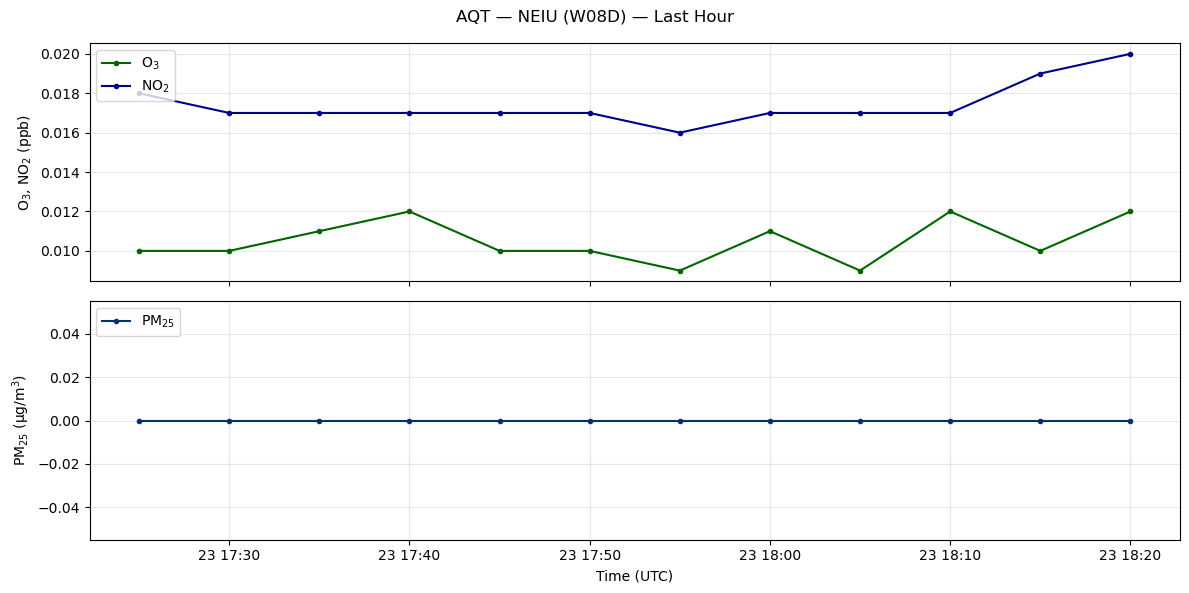

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(aqt_last_hour.index, aqt_last_hour['o3'],
         marker='o', markersize=3, label='O$_3$', color='darkgreen')
ax1.plot(aqt_last_hour.index, aqt_last_hour['no2'],
         marker='o', markersize=3, label='NO$_2$', color='darkblue')
ax1.set_ylabel('O$_3$, NO$_2$ (ppb)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(aqt_last_hour.index, aqt_last_hour['pm25'],
         marker='o', markersize=3, label='PM$_{25}$', color='#08306b')
ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
ax2.set_xlabel('Time (UTC)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

fig.suptitle(f'AQT — {SITE_NAME[VSN]} ({VSN}) — Last Hour', fontsize=12)
fig.tight_layout()
plt.show()

## Data with Specified Date Range

In [9]:
# This can take 1.5s to run
START = "2023-06-01"  # start is at the beginning of this day
END   = "2023-06-02"  # end is at the beginning of this day

df_aqt = query_aqt(VSN,START,END)

This takes ~7 minutes for 2023 data due to >1Hz historical sampling rate.

In [10]:
# This can take 5-7 min to run.
df_wxt = query_wxt(VSN,START,END)

In [11]:
print(f"df_aqt: {df_aqt.shape}, {df_aqt.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"df_wxt: {df_wxt.shape}, {df_wxt.memory_usage(deep=True).sum() / 1e6:.2f} MB")

df_aqt: (288, 12), 0.06 MB
df_wxt: (288, 8), 0.05 MB


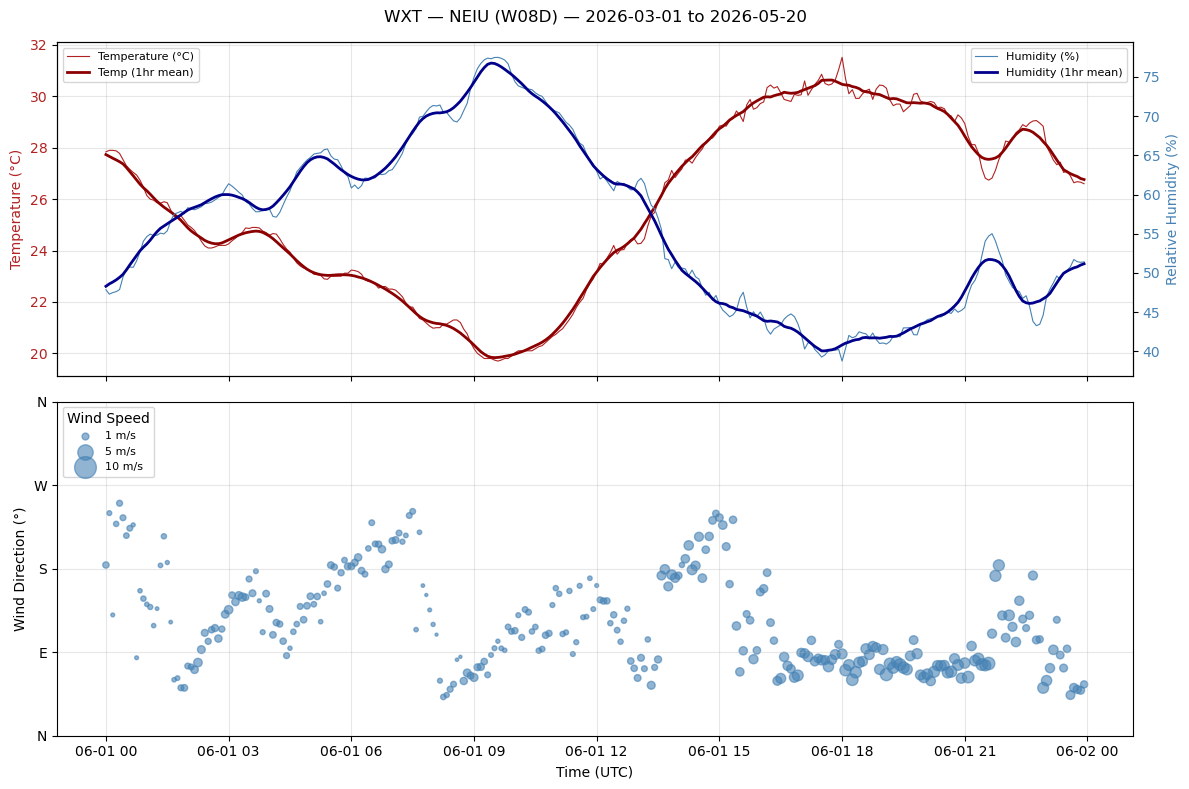

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Panel 1: Temperature and Humidity ---
ax1.plot(df_wxt.index, df_wxt['temp'],
         color='firebrick', linewidth=0.8, label='Temperature (°C)')
ax1.plot(df_wxt.index,
         df_wxt['temp'].rolling('60min', center=True).mean(),
         color='darkred', linewidth=2, label='Temp (1hr mean)')
ax1.set_ylabel('Temperature (°C)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(df_wxt.index, df_wxt['humidity'],
          color='steelblue', linewidth=0.8, label='Humidity (%)')
ax1b.plot(df_wxt.index,
          df_wxt['humidity'].rolling('60min', center=True).mean(),
          color='darkblue', linewidth=2, label='Humidity (1hr mean)')
ax1b.set_ylabel('Relative Humidity (%)', color='steelblue')
ax1b.tick_params(axis='y', labelcolor='steelblue')

ax1.legend(loc='upper left', fontsize=8)
ax1b.legend(loc='upper right', fontsize=8)

# --- Panel 2: Wind direction, dot size proportional to wind speed ---
# Normalize wind speed for marker size — scale to reasonable dot range
speed        = df_wxt['wind_speed'].fillna(0)
marker_sizes = (speed / speed.max() * 80).clip(lower=2)

ax2.scatter(df_wxt.index, df_wxt['wind_dir'],
            s=marker_sizes,
            color='steelblue', alpha=0.6)
ax2.set_ylabel('Wind Direction (°)')
ax2.set_ylim(0, 360)
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.set_yticklabels(['N', 'E', 'S', 'W', 'N'])
ax2.set_xlabel('Time (UTC)')
ax2.grid(True, alpha=0.3)

# Add a size legend for wind speed
for speed_val, label in [(1, '1 m/s'), (5, '5 m/s'), (10, '10 m/s')]:
    size = speed_val / df_wxt['wind_speed'].max() * 80
    ax2.scatter([], [], s=max(size, 2), color='steelblue',
                alpha=0.6, label=label)
ax2.legend(loc='upper left', fontsize=8, title='Wind Speed')

fig.suptitle(f'WXT — {SITE_NAME[VSN]} ({VSN}) — {START} to {END}',
             fontsize=12)
fig.tight_layout()
plt.show()

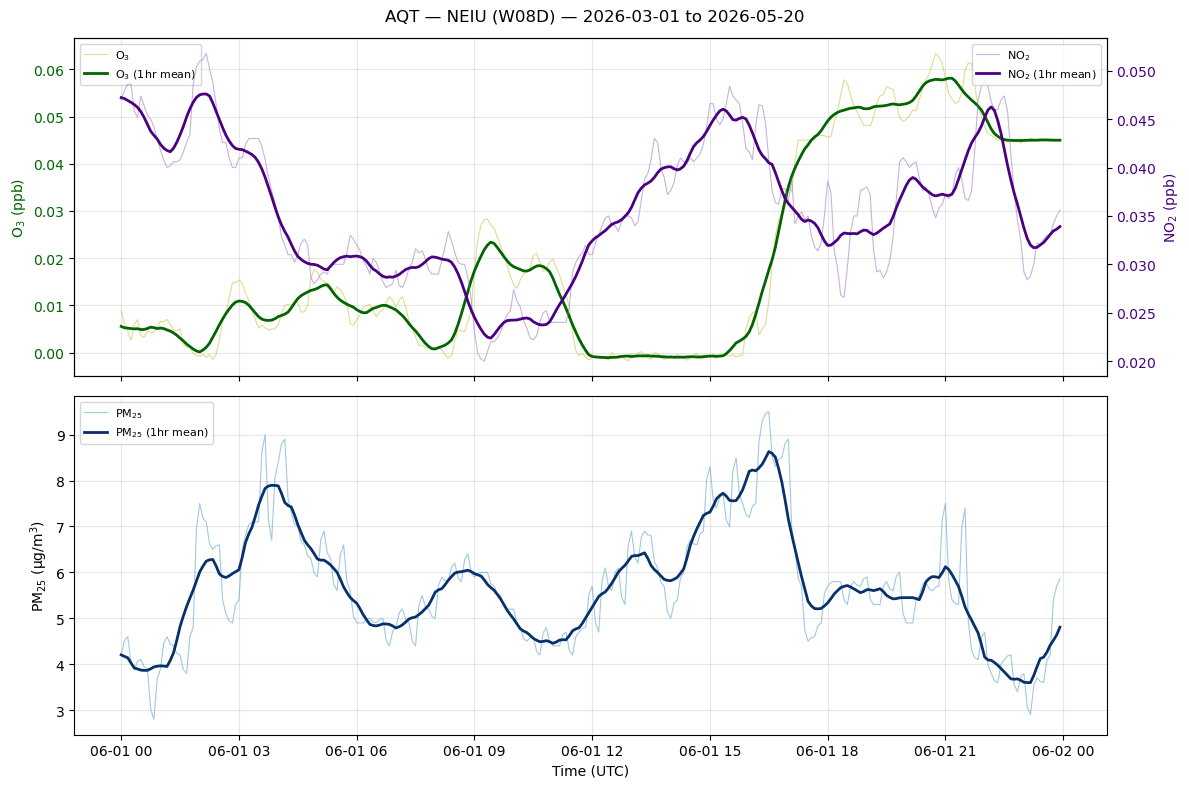

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Panel 1: O3 and NO2 ---
ax1.plot(df_aqt.index, df_aqt['o3'],
         color='tab:olive', linewidth=0.8, alpha=0.5, label='O$_3$')
ax1.plot(df_aqt.index,
         df_aqt['o3'].rolling('60min', center=True).mean(),
         color='darkgreen', linewidth=2, label='O$_3$ (1hr mean)')
ax1.set_ylabel('O$_3$ (ppb)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(df_aqt.index, df_aqt['no2'],
          color='tab:purple', linewidth=0.8, alpha=0.5, label='NO$_2$')
ax1b.plot(df_aqt.index,
          df_aqt['no2'].rolling('60min', center=True).mean(),
          color='indigo', linewidth=2, label='NO$_2$ (1hr mean)')
ax1b.set_ylabel('NO$_2$ (ppb)', color='indigo')
ax1b.tick_params(axis='y', labelcolor='indigo')

ax1.legend(loc='upper left', fontsize=8)
ax1b.legend(loc='upper right', fontsize=8)

# --- Panel 2: PM2.5 ---
ax2.plot(df_aqt.index, df_aqt['pm25'],
         color='#4393c3', linewidth=0.8, alpha=0.5, label='PM$_{25}$')
ax2.plot(df_aqt.index,
         df_aqt['pm25'].rolling('60min', center=True).mean(),
         color='#08306b', linewidth=2, label='PM$_{25}$ (1hr mean)')
ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
ax2.set_xlabel('Time (UTC)')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle(f'AQT — {SITE_NAME[VSN]} ({VSN}) — {START} to {END}',
             fontsize=12)
fig.tight_layout()
plt.show()

## Sap Flow

In [12]:
start, end = last_n_hours(24)
sapflow = query_sapflow(VSN, start, end)

# Show which trees returned data
print("Trees with data:", list(sapflow.keys()))

# Inspect one tree
if sapflow:
    first = list(sapflow.keys())[0]
    print(f"\n{first}:")
    print(sapflow[first].head())
    print(sapflow[first].dtypes)

Trees with data: ['white_oak_2', 'sugar_maple_1', 'sugar_maple_2', 'sugar_maple_3']

white_oak_2:
name                                 battery_voltage  inner   outer   vsn  \
timestamp                                                                   
2026-05-22 18:47:54.354948096+00:00             4.19  5.264  10.356  W08D   
2026-05-22 19:02:54.097191936+00:00             4.19  5.433  10.321  W08D   
2026-05-22 19:17:56.016512+00:00                4.19  5.231  10.236  W08D   
2026-05-22 19:32:50.735136+00:00                4.19  5.369  10.308  W08D   
2026-05-22 20:47:54.736377088+00:00             4.17  5.187  10.526  W08D   

name                                   serial  
timestamp                                      
2026-05-22 18:47:54.354948096+00:00  SX61NA0X  
2026-05-22 19:02:54.097191936+00:00  SX61NA0X  
2026-05-22 19:17:56.016512+00:00     SX61NA0X  
2026-05-22 19:32:50.735136+00:00     SX61NA0X  
2026-05-22 20:47:54.736377088+00:00  SX61NA0X  
name
battery_voltage    fl

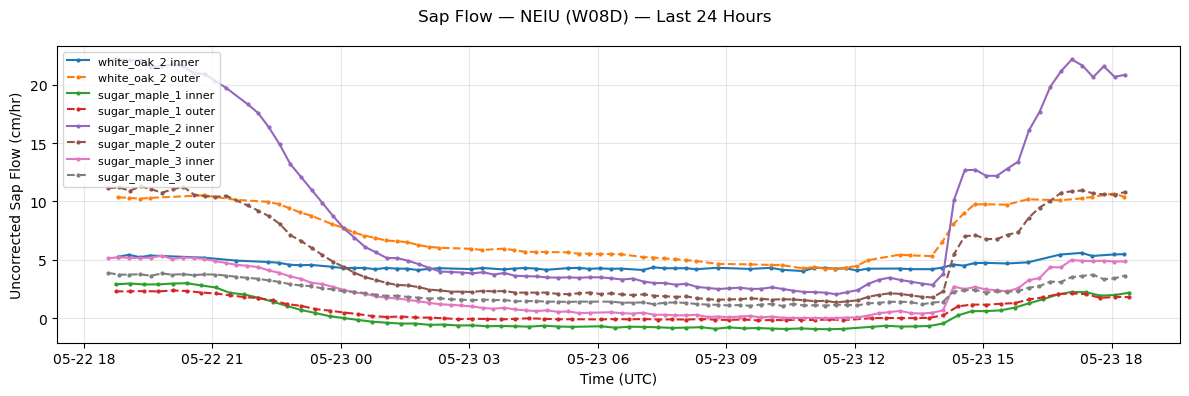

In [13]:
if sapflow:
    fig, ax = plt.subplots(figsize=(12, 4))

    for label, df in sapflow.items():
        ax.plot(df.index, df['inner'],
                marker='o', markersize=2, label=f'{label} inner')
        ax.plot(df.index, df['outer'],
                marker='o', markersize=2, linestyle='--', label=f'{label} outer')

    ax.set_ylabel('Uncorrected Sap Flow (cm/hr)')
    ax.set_xlabel('Time (UTC)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.suptitle(f'Sap Flow — {SITE_NAME[VSN]} ({VSN}) — Last 24 Hours', fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    print("No sap flow data available.")

## Multi-Function Research (MFR) Data

Long Range Wide Area (LoRaWAN)-enabled nodes 

In [14]:
#start, end = last_n_hours(24)   # Last 24 hours
START = '2026-03-01'
END   = '2026-05-20'
mfr = query_mfr(VSN, START, END)

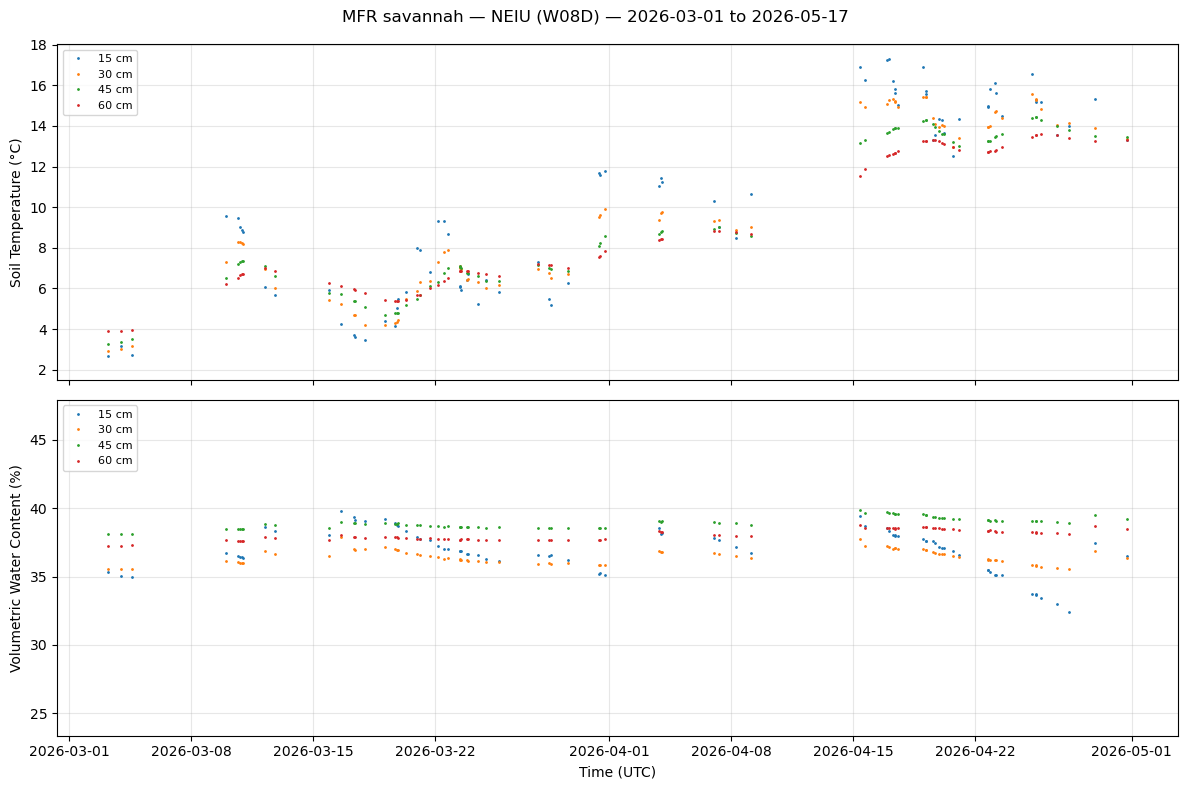

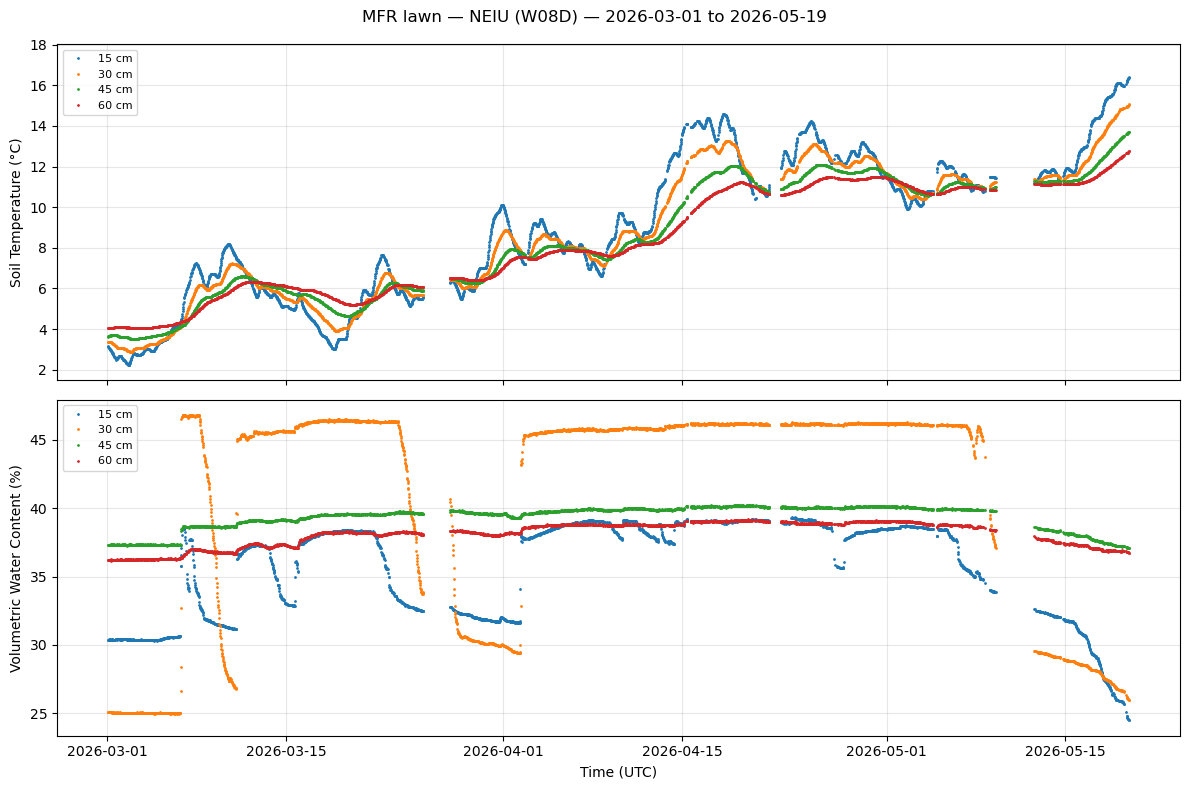

In [15]:
if mfr:
    # Compute common y-axis limits across all sites
    temp_min = min(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].min().min() 
                   for df in mfr.values())
    temp_max = max(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].max().max() 
                   for df in mfr.values())
    vwc_min  = min(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].min().min() 
                   for df in mfr.values())
    vwc_max  = max(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].max().max() 
                   for df in mfr.values())

    # Add a small margin
    temp_pad = (temp_max - temp_min) * 0.05
    vwc_pad  = (vwc_max  - vwc_min)  * 0.05

    for label, df in mfr.items():
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        for col, depth in [('temp_15cm', '15 cm'), ('temp_30cm', '30 cm'),
                            ('temp_45cm', '45 cm'), ('temp_60cm', '60 cm')]:
            if col in df.columns:
                ax1.plot(df.index, df[col],
                         linestyle='none', marker='o', markersize=1,
                         label=depth)
        ax1.set_ylim(temp_min - temp_pad, temp_max + temp_pad)
        ax1.set_ylabel('Soil Temperature (°C)')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.grid(True, alpha=0.3)

        for col, depth in [('vwc_15cm', '15 cm'), ('vwc_30cm', '30 cm'),
                            ('vwc_45cm', '45 cm'), ('vwc_60cm', '60 cm')]:
            if col in df.columns:
                ax2.plot(df.index, df[col],
                         linestyle='none', marker='o', markersize=1,
                         label=depth)
        ax2.set_ylim(vwc_min - vwc_pad, vwc_max + vwc_pad)
        ax2.set_ylabel('Volumetric Water Content (%)')
        ax2.set_xlabel('Time (UTC)')
        ax2.legend(loc='upper left', fontsize=8)
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'MFR {label} — {SITE_NAME[VSN]} ({VSN}) — {df.index.min().date()} to {df.index.max().date()}',
                     fontsize=12)
        fig.tight_layout()
        plt.savefig(f'figures/mfr_{label}_soil.png', dpi=150, bbox_inches='tight')
        plt.show()

NB The savannah soil texture is mostly clay which may be responsible for saturation and the narrow range of VWC.

In [16]:
# Simple soil statistics

if mfr:
    for label, df in mfr.items():
        print(f"\n{label}:")
        print(f"  Shape: {df.shape}")
        print(f"  Date range: {df.index.min()} to {df.index.max()}")
        print(f"\n  Column statistics:")
        cols = ['temp_15cm', 'temp_30cm', 'temp_45cm', 'temp_60cm',
                'vwc_15cm',  'vwc_30cm',  'vwc_45cm',  'vwc_60cm']
        for col in cols:
            if col in df.columns:
                valid = df[col].dropna()
                print(f"  {col:12}: n={len(valid):4d}  "
                      f"min={valid.min():7.2f}  "
                      f"max={valid.max():7.2f}  "
                      f"mean={valid.mean():7.2f}")


savannah:
  Shape: (723, 21)
  Date range: 2026-03-01 05:10:39.064961792+00:00 to 2026-05-17 15:20:36.573684992+00:00

  Column statistics:
  temp_15cm   : n=  80  min=   2.69  max=  17.28  mean=  10.33
  temp_30cm   : n=  80  min=   2.91  max=  15.59  mean=   9.89
  temp_45cm   : n=  80  min=   3.28  max=  14.44  mean=   9.46
  temp_60cm   : n=  80  min=   3.91  max=  13.59  mean=   9.17
  vwc_15cm    : n=  80  min=  32.41  max=  39.76  mean=  36.90
  vwc_30cm    : n=  80  min=  35.52  max=  37.88  mean=  36.45
  vwc_45cm    : n=  80  min=  38.10  max=  39.86  mean=  38.93
  vwc_60cm    : n=  80  min=  37.27  max=  38.75  mean=  38.04

lawn:
  Shape: (15349, 21)
  Date range: 2026-03-01 00:01:19.310976+00:00 to 2026-05-19 23:30:19.231257088+00:00

  Column statistics:
  temp_15cm   : n=2998  min=   2.25  max=  16.41  mean=   8.84
  temp_30cm   : n=2997  min=   2.88  max=  15.06  mean=   8.57
  temp_45cm   : n=2996  min=   3.50  max=  13.69  mean=   8.30
  temp_60cm   : n=2995  min=  